In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
#read the data

df = pd.read_excel('Tudo Gostoso.xlsx', sheet_name='analysis')
df = df[df['CF total (gCO2e)'] != 0]

print(df['CF total (gCO2e)'])

ingredients = df['Ingredient']
carbon = df['CF total (gCO2e)']
weight = df['Total g']
frequency = df['frequency']



0       3755.700000
1       4956.432000
2      15974.010000
3      25671.271950
4      12337.986000
           ...     
141        7.332000
142        6.552000
148        0.505500
149        1.599000
150        0.341213
Name: CF total (gCO2e), Length: 119, dtype: float64


In [40]:
print(frequency.max())
print(weight.max())
print(carbon.max())
print(frequency.min())
print(weight.min())
print(carbon.min())

62
14445.0
101206.066
1
1.0125000000000002
0.34121250000000003


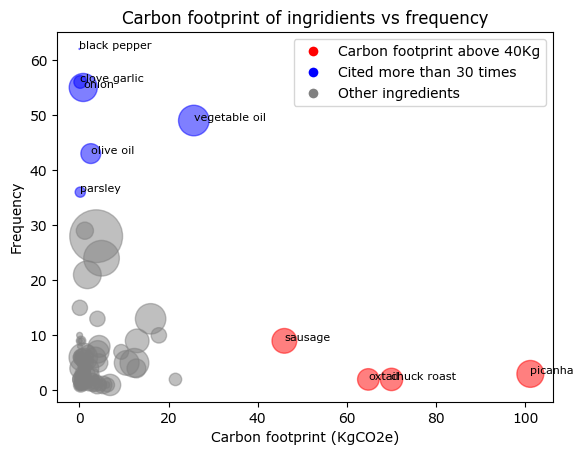

In [73]:
y_maximum = 30
x_maximum = 40000

colors = []
for i in range(len(ingredients)):
    if carbon.iloc[i] > x_maximum or frequency.iloc[i] > y_maximum:
        plt.text(carbon.iloc[i]/1000, frequency.iloc[i], ingredients.iloc[i], 
            fontsize=8)
        if carbon.iloc[i] > x_maximum:
            color = 'red' 
            colors.append(color)
        if frequency.iloc[i] > y_maximum:
            color = 'blue'
            colors.append(color)
    else:
        color = 'gray'
        colors.append(color)
# Labels 
plt.scatter(carbon/1000, frequency, c=colors, s=weight/10, alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('Carbon footprint (KgCO2e)')



legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Carbon footprint above 40Kg',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Cited more than 30 times',
           markerfacecolor='blue', markersize=8),       
    Line2D([0], [0], marker='o', color='w', label='Other ingredients',
           markerfacecolor='gray', markersize=8)
]

plt.legend(handles=legend_elements)
plt.title('Carbon footprint of ingridients vs frequency')
plt.show()